In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("programmer3/lithium-ion-battery-degradation-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abhishek\.cache\kagglehub\datasets\programmer3\lithium-ion-battery-degradation-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
df = pd.read_csv('Battery_dataset.csv')

In [4]:
df.head()

,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215


In [5]:
# 3 different batteries, 5,6,7, with cycle count, charge current, voltage and time with discharge current voltage time
# and battery capacity, state of health and remaining useful life

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   battery_id  680 non-null    object 
 1   cycle       680 non-null    int64  
 2   chI         680 non-null    float64
 3   chV         680 non-null    float64
 4   chT         680 non-null    float64
 5   disI        680 non-null    float64
 6   disV        680 non-null    float64
 7   disT        680 non-null    float64
 8   BCt         680 non-null    float64
 9   SOH         680 non-null    float64
 10  RUL         680 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 58.6+ KB


In [7]:
df['battery_id'].value_counts()

battery_id
B7    250
B5    220
B6    210
Name: count, dtype: int64

In [8]:
df['battery_id'] = df['battery_id'].astype('category')

In [9]:
df['battery_id'].cat.codes

0      0
1      0
2      0
3      0
4      0
      ..
675    2
676    2
677    2
678    2
679    2
Length: 680, dtype: int8

In [10]:
df['onehot_battery'] = df['battery_id'].cat.codes

In [11]:
df.head()

,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL,onehot_battery
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219,0
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218,0
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217,0
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216,0
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215,0


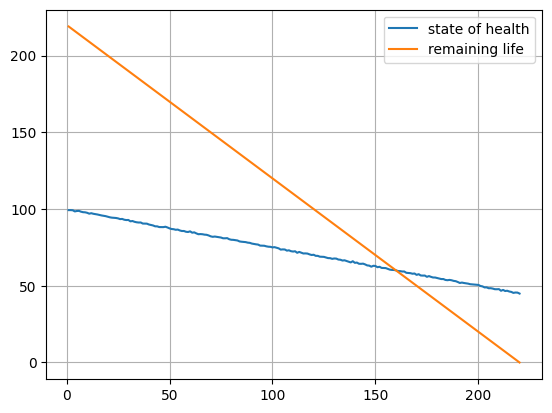

In [12]:
battery1= df[df['onehot_battery']==0]
plt.plot(battery1['cycle'], battery1['SOH'], label='state of health')
plt.plot(battery1['cycle'], battery1['RUL'], label='remaining life')
plt.grid()
plt.legend()
plt.savefig('images\\battery data example.png', bbox_inches='tight', dpi=300)
plt.show()

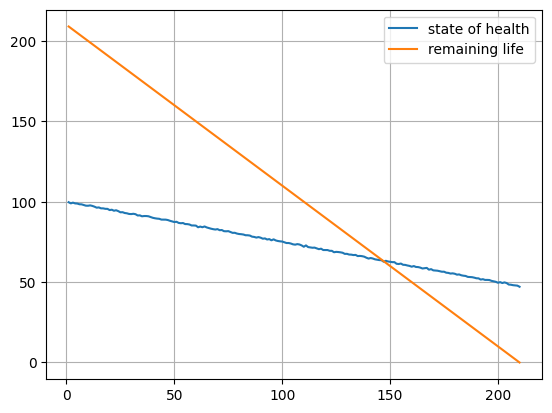

In [13]:
battery2= df[df['onehot_battery']==1]
plt.plot(battery2['cycle'], battery2['SOH'], label='state of health')
plt.plot(battery2['cycle'], battery2['RUL'], label='remaining life')
plt.grid()
plt.legend()
plt.show()

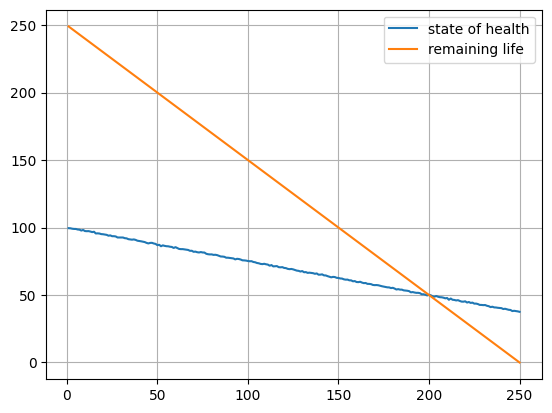

In [14]:
battery3= df[df['onehot_battery']==2]
plt.plot(battery3['cycle'], battery3['SOH'], label='state of health')
plt.plot(battery3['cycle'], battery3['RUL'], label='remaining life')
plt.grid()
plt.legend()
plt.show()

In [15]:
# first , we go for SOH

In [16]:
df.columns

Index(['battery_id', 'cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT',
       'BCt', 'SOH', 'RUL', 'onehot_battery'],
      dtype='object')

In [17]:
features = ['cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT','BCt', 'onehot_battery']

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
df[features[1:-1]] = scaler.fit_transform(df[features[1:-1]])

In [20]:
df.head()

,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL,onehot_battery
0,B5,1,0.389761,1.106045,-1.936136,-1.158594,-0.748667,-0.065200,1.676687,99.309790,219,0
1,B5,2,0.160713,-0.914821,-0.809930,-1.818173,1.769025,-0.461085,1.676819,99.311985,218,0
2,B5,3,0.196472,1.567095,-0.982854,-0.670503,-0.943082,1.114364,1.670850,99.212608,217,0
3,B5,4,-0.606741,0.722881,0.133432,0.674825,-1.205980,-0.556882,1.625758,98.461812,216,0
4,B5,5,-1.323808,-1.277705,-0.263822,0.432385,0.751051,-0.337741,1.642652,98.743106,215,0


In [21]:
seq_len = 10

In [22]:
seq = []
soh_list = []
rul_list = []

for b in range(0,3):
    df_battery = df[df['onehot_battery'] == b]
    feat = df_battery[features].values
    soh = df_battery['SOH'].values
    rul = df_battery['RUL'].values

    for i in range(len(df_battery)-seq_len):
        seq.append(feat[i:i+seq_len])
        soh_list.append(soh[i+seq_len])
        rul_list.append(rul[i+seq_len])

In [23]:
seq = np.stack(seq)

In [24]:
seq.shape

(650, 10, 9)

In [25]:
seq[0]

array([[ 1.        ,  0.38976113,  1.10604501, -1.93613595, -1.15859383,
        -0.74866686, -0.06519996,  1.67668688,  0.        ],
       [ 2.        ,  0.160713  , -0.91482094, -0.80993001, -1.8181732 ,
         1.76902465, -0.46108498,  1.67681875,  0.        ],
       [ 3.        ,  0.1964717 ,  1.56709468, -0.98285402, -0.6705032 ,
        -0.94308166,  1.11436366,  1.67085023,  0.        ],
       [ 4.        , -0.60674079,  0.72288097,  0.13343186,  0.67482547,
        -1.20597966, -0.55688198,  1.62575798,  0.        ],
       [ 5.        , -1.32380834, -1.27770529, -0.26382222,  0.43238484,
         0.75105095, -0.33774133,  1.6426523 ,  0.        ],
       [ 6.        ,  1.0607972 , -1.19451306, -0.26026616,  0.39706296,
        -1.73441983,  1.13493132,  1.64696697,  0.        ],
       [ 7.        , -0.2456131 ,  0.41894218, -0.60051889, -0.37700651,
         0.15802429,  0.07137366,  1.61513186,  0.        ],
       [ 8.        ,  0.26757421, -0.34479865,  0.25198717, -1

In [26]:
soh = np.array(soh_list).reshape(-1,1)

In [27]:
soh[0]

array([96.99057262])

In [28]:
rul = np.array(rul_list).reshape(-1,1)

In [29]:
rul[0]

array([209])

In [30]:
seq=torch.FloatTensor(seq)

In [31]:
seq.shape

torch.Size([650, 10, 9])

In [32]:
soh = torch.FloatTensor(soh)

In [33]:
soh.shape

torch.Size([650, 1])

In [34]:
rul = torch.FloatTensor(rul)

In [35]:
rul.shape

torch.Size([650, 1])

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
xtr,xts,ytr,yts = train_test_split(seq,soh, test_size=0.2, shuffle=True)

In [38]:
xtr.shape

torch.Size([520, 10, 9])

In [39]:
xts.shape

torch.Size([130, 10, 9])

In [40]:
from torch.utils.data import TensorDataset, DataLoader

In [41]:
train_data = TensorDataset(xtr,ytr)
test_data = TensorDataset(xts,yts)

In [42]:
train_data

In [43]:
train_loader = DataLoader(train_data, batch_size=52, shuffle=True)
test_loader = DataLoader(test_data, batch_size = 13, shuffle = False )

In [44]:
train_loader

In [45]:
test_loader

In [46]:
epochs = 200
num_layers = 1
hidden_size = 100
input_size=9

In [47]:
lstm = nn.LSTM(input_size,hidden_size, num_layers,batch_first=True)

In [48]:
for x,y in train_loader:
    break

In [49]:
lstm_out, hidden_out = lstm(x)

In [50]:
lstm_out.shape

torch.Size([52, 10, 100])

In [51]:
lstm_out[:,-1,:].shape

torch.Size([52, 100])

In [52]:
class lstmmodel(nn.Module):
    def __init__(self, num_layers, hidden_size, input_size):
        super().__init__()
        
        self.hidden = hidden_size

        self.lstm = nn.LSTM(input_size,hidden_size, num_layers,batch_first=True)
        self.fc = nn.Linear(hidden_size,1)
        
    def forward(self,x):
        lstm_out , hidden_out = self.lstm(x)
        fc_out = self.fc(lstm_out[:,-1,:])

        return fc_out

In [53]:
soh_model = lstmmodel(num_layers, hidden_size, input_size)

In [54]:
soh_model

lstmmodel(
  (lstm): LSTM(9, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

In [55]:
for param in soh_model.parameters():
    print(param.numel())

3600
40000
400
400
100
1


In [56]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(soh_model.parameters(), lr=0.01)

In [57]:
torch.cuda.is_available()

True

In [58]:
soh_model.cuda()

lstmmodel(
  (lstm): LSTM(9, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

In [59]:
train_loss=[]
test_loss=[]
tracker = 0
for epoch in range(epochs):
    soh_model.train()

    for x,y in train_loader:
        tracker +=1
        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        pred = soh_model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

    train_loss.append(loss.cpu().detach().item())


    soh_model.eval()
    with torch.no_grad():
        for x,y in test_loader:
                
            x = x.cuda()
            y = y.cuda()

            pred = soh_model(x)
            loss = criterion(pred,y)

        test_loss.append(loss.cpu().detach().item())
        
    
    print(f"epoch: {epoch+1}, Training loss:{train_loss[-1]}, Val_loss:{test_loss[-1]}")

epoch: 1, Training loss:4375.3955078125, Val_loss:3695.548828125
epoch: 2, Training loss:3049.07666015625, Val_loss:2786.4755859375
epoch: 3, Training loss:2417.765869140625, Val_loss:2002.4527587890625
epoch: 4, Training loss:1353.5400390625, Val_loss:1381.681884765625
epoch: 5, Training loss:1211.802001953125, Val_loss:930.8270263671875
epoch: 6, Training loss:777.2005004882812, Val_loss:627.1669311523438
epoch: 7, Training loss:657.529296875, Val_loss:433.34991455078125
epoch: 8, Training loss:347.0797119140625, Val_loss:320.5284729003906
epoch: 9, Training loss:403.4737854003906, Val_loss:263.27960205078125
epoch: 10, Training loss:313.75396728515625, Val_loss:236.81761169433594
epoch: 11, Training loss:282.1384582519531, Val_loss:227.26422119140625
epoch: 12, Training loss:240.87571716308594, Val_loss:226.09136962890625
epoch: 13, Training loss:273.2718811035156, Val_loss:227.61549377441406
epoch: 14, Training loss:217.6643524169922, Val_loss:229.79551696777344
epoch: 15, Training

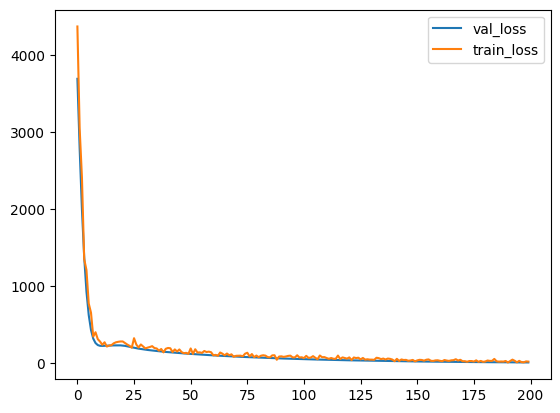

In [60]:
plt.plot(range(epochs), test_loss, label='val_loss')
plt.plot(range(epochs), train_loss, label='train_loss')
plt.legend()
plt.savefig('images\\soh training.png', bbox_inches='tight', dpi=300)
plt.show()

In [61]:
y_pred=[]
y_true=[]

with torch.no_grad():
    for x,y in test_loader:
        x = x.cuda()
        y = y.cuda()

        pred = soh_model(x)
        loss = criterion(pred,y)

        y_true.append(y.cpu().detach().numpy())
        y_pred.append(pred.cpu().detach().numpy())

In [62]:
y_true = np.concatenate(y_true).flatten()
y_pred = np.concatenate(y_pred).flatten()

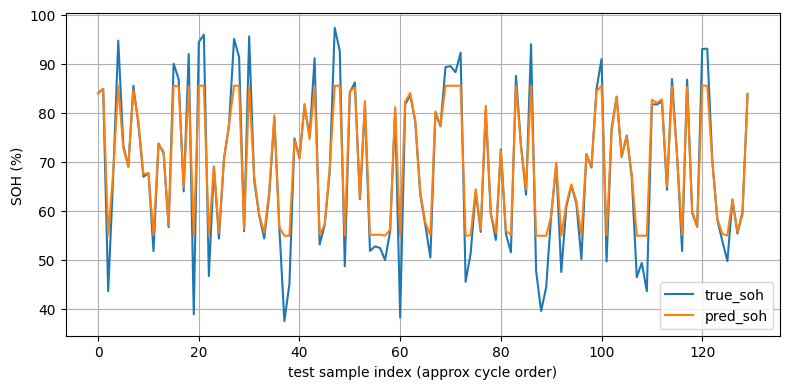

In [63]:
plt.figure(figsize=(8,4))
plt.plot(y_true, label="true_soh")
plt.plot(y_pred, label="pred_soh")
plt.xlabel("test sample index (approx cycle order)")
plt.ylabel("SOH (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images\\soh eval.png', bbox_inches='tight', dpi=300)
plt.show()

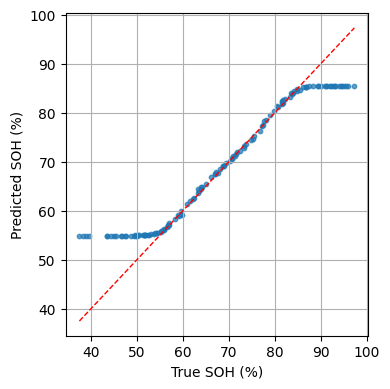

In [64]:
plt.figure(figsize=(4,4))
plt.scatter(y_true, y_pred, s=10, alpha=0.7)
lims = [min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)  
plt.xlabel("True SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig('images\\soh true vs pred.png', bbox_inches='tight', dpi=300)
plt.show()

In [65]:
#now for rul

In [66]:
xtr,xts,ytr,yts = train_test_split(seq,rul, test_size=0.2, shuffle=True)

In [67]:
train_data = TensorDataset(xtr,ytr)
test_data = TensorDataset(xts,yts)

In [68]:
train_loader = DataLoader(train_data, batch_size=52, shuffle=True)
test_loader = DataLoader(test_data, batch_size = 13, shuffle = False )

In [69]:
epochs = 200
num_layers = 1
hidden_size = 150
input_size=9

In [70]:
rul_model = lstmmodel(num_layers, hidden_size, input_size)

In [71]:
rul_model

lstmmodel(
  (lstm): LSTM(9, 150, batch_first=True)
  (fc): Linear(in_features=150, out_features=1, bias=True)
)

In [72]:
rul_model.cuda()

lstmmodel(
  (lstm): LSTM(9, 150, batch_first=True)
  (fc): Linear(in_features=150, out_features=1, bias=True)
)

In [73]:
train_loss=[]
test_loss=[]
tracker = 0
for epoch in range(epochs):
    soh_model.train()

    for x,y in train_loader:
        tracker +=1
        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        pred = soh_model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

    train_loss.append(loss.cpu().detach().item())


    soh_model.eval()
    with torch.no_grad():
        for x,y in test_loader:
                
            x = x.cuda()
            y = y.cuda()

            pred = soh_model(x)
            loss = criterion(pred,y)

        test_loss.append(loss.cpu().detach().item())
        
    
    print(f"epoch: {epoch+1}, Training loss:{train_loss[-1]}, Val_loss:{test_loss[-1]}")

epoch: 1, Training loss:2323.833251953125, Val_loss:3487.95751953125
epoch: 2, Training loss:3126.57763671875, Val_loss:2699.283203125
epoch: 3, Training loss:2842.877197265625, Val_loss:2637.89794921875
epoch: 4, Training loss:2589.141357421875, Val_loss:2576.05126953125
epoch: 5, Training loss:2646.818115234375, Val_loss:2562.814453125
epoch: 6, Training loss:3222.792236328125, Val_loss:2530.193603515625
epoch: 7, Training loss:2478.318359375, Val_loss:2457.853759765625
epoch: 8, Training loss:2829.334228515625, Val_loss:2408.61181640625
epoch: 9, Training loss:2385.042236328125, Val_loss:2364.329833984375
epoch: 10, Training loss:2616.461669921875, Val_loss:2295.337890625
epoch: 11, Training loss:2750.09228515625, Val_loss:2208.459228515625
epoch: 12, Training loss:2705.022705078125, Val_loss:2134.37353515625
epoch: 13, Training loss:2098.21630859375, Val_loss:2070.58935546875
epoch: 14, Training loss:1646.9068603515625, Val_loss:2003.9757080078125
epoch: 15, Training loss:1116.5471

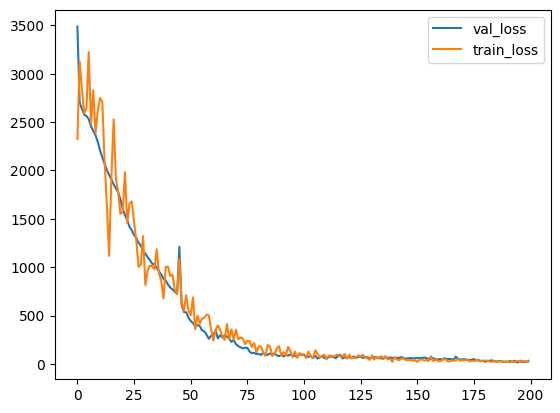

In [74]:
plt.plot(range(epochs), test_loss, label='val_loss')
plt.plot(range(epochs), train_loss, label='train_loss')
plt.legend()
plt.show()

In [75]:
y_pred=[]
y_true=[]

with torch.no_grad():
    for x,y in test_loader:
        x = x.cuda()
        y = y.cuda()

        pred = soh_model(x)
        loss = criterion(pred,y)

        y_true.append(y.cpu().detach().numpy())
        y_pred.append(pred.cpu().detach().numpy())

In [76]:
y_true = np.concatenate(y_true).flatten()
y_pred = np.concatenate(y_pred).flatten()

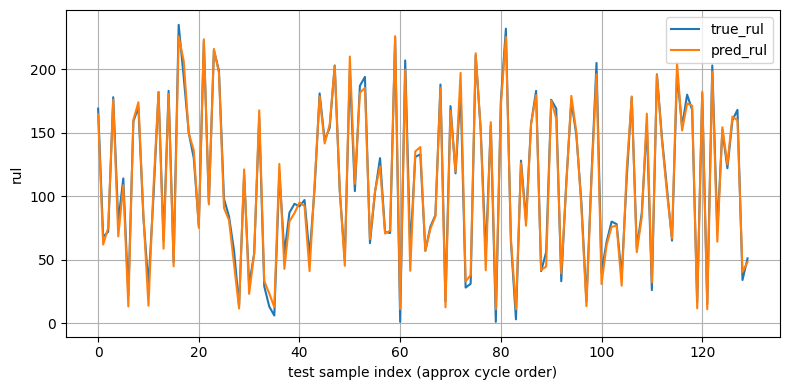

In [77]:
plt.figure(figsize=(8,4))
plt.plot(y_true, label="true_rul")
plt.plot(y_pred, label="pred_rul")
plt.xlabel("test sample index (approx cycle order)")
plt.ylabel("rul")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

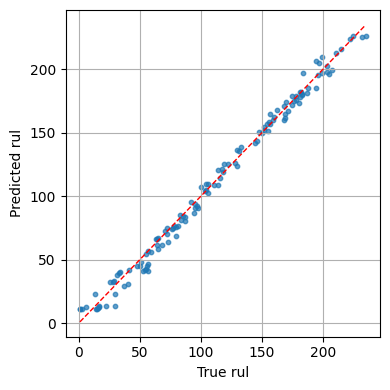

In [78]:
plt.figure(figsize=(4,4))
plt.scatter(y_true, y_pred, s=10, alpha=0.7)
lims = [min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)  
plt.xlabel("True rul")
plt.ylabel("Predicted rul")
plt.grid(True)
plt.tight_layout()
plt.show()